In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "flowmap_legacy").exists():
        sys.path.insert(0, str(parent))
        break
else:
    raise RuntimeError("Could not find flowmap_legacy from the current working directory")

from flowmap_legacy.plotting import *

def make_s_curve(n_samples=100, noise=0.0, random_state=None):
    """Generate an S curve dataset.

    Parameters
    ----------
    n_samples : int, default=100
        The number of sample points on the S curve.

    noise : float, default=0.0
        The standard deviation of the gaussian noise.

    random_state : int, Generator instance, or None, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.

    Returns
    -------
    X : ndarray of shape (n_samples, 3)
        The points.

    t : ndarray of shape (n_samples,)
        The univariate position of the sample according
        to the main dimension of the points in the manifold.
    """
    # Create a Generator instance
    rng = np.random.default_rng(random_state)

    t = 3 * np.pi * (rng.uniform(size=n_samples) - 0.5)
    X = np.empty(shape=(n_samples, 3), dtype=np.float64)
    X[:, 0] = np.sin(t)
    X[:, 1] = 2.0 * rng.uniform(size=n_samples)
    X[:, 2] = np.sign(t) * (np.cos(t) - 1)
    X += noise * rng.standard_normal(size=(n_samples, 3))
    t = np.squeeze(t)
    return X, t

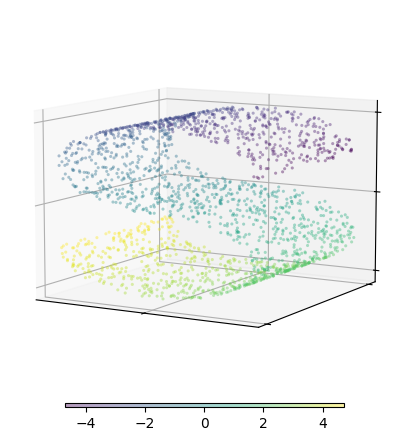

In [3]:
n = 2000

X, t = make_s_curve(n, random_state=42)
plot_3d(X, t, "")

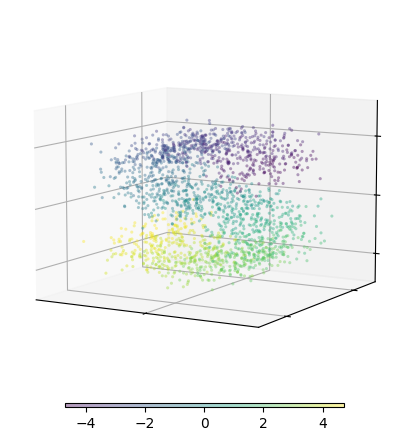

In [4]:
# Set seed for reproducibility
np.random.seed(42)

# Define noise level
noise_std = 0.25

# Add Gaussian noise to the position and velocity matrices
X_noisy = X + np.random.normal(scale=noise_std, size=X.shape)
plot_3d(X_noisy, t, "")

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


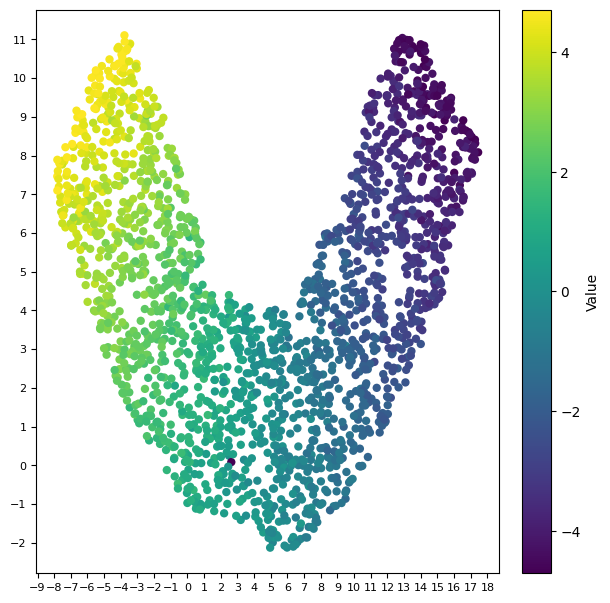

In [24]:
import umap

umap_reducer = umap.UMAP(n_neighbors=30, min_dist=0.6, n_components=2, random_state=1)
X_2d = umap_reducer.fit_transform(X_noisy)
plot_2d(X_2d, t, "")

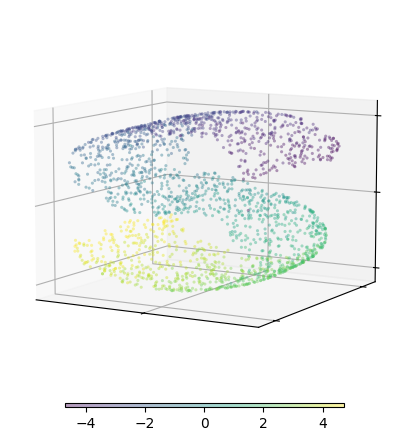

In [25]:
from flowmap_legacy.TPS import *

tps = ThinPlateSpline(X_2d, n_control_points=500)
tps.fit(X_noisy, dof_target=30)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from flowmap_legacy.TPS import ThinPlateSpline

# Define the range of degrees of freedom to test in log space
dof_targets = np.logspace(np.log10(20), np.log10(410), 11)  # Logarithmically spaced values

# Store the computed metrics
rmse_values = []
r2_values = []
gcv_values = []
rmse_gt_values = []

# Create TPS model
n_control_points = 1000  # Adjust as needed
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)

# Iterate over different degrees of freedom
for dof_target in dof_targets:
    print(f"Running with dof: {dof_target:.2f}")
    tps.fit(X_noisy, dof_target=dof_target)
    metrics = tps.evaluate_fit(X_noisy)
    
    # Compute RMSE with ground truth
    X_smoothed = tps.predict(X_2d)
    RSS_gt = np.sum((X - X_smoothed) ** 2)
    RMSE_gt = np.sqrt(RSS_gt / (X.shape[0] * X.shape[1]))

    # Store metrics
    rmse_values.append(metrics["RMSE"])
    r2_values.append(metrics["R2"])
    gcv_values.append(metrics["GCV"])
    rmse_gt_values.append(RMSE_gt)

Running with dof: 20.00
Running with dof: 27.05
Running with dof: 36.59
Running with dof: 49.49
Running with dof: 66.95
Running with dof: 90.55
Running with dof: 122.48
Running with dof: 165.68
Running with dof: 224.10
Running with dof: 303.12
Running with dof: 410.00


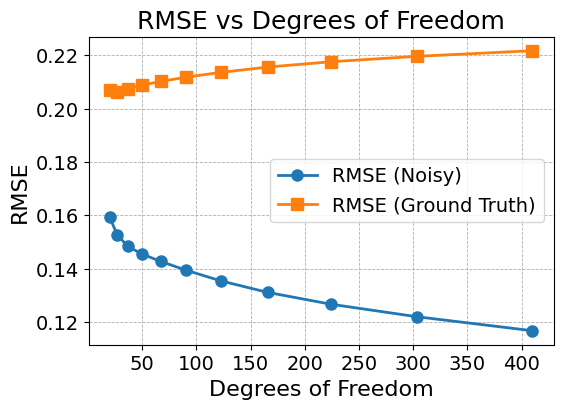

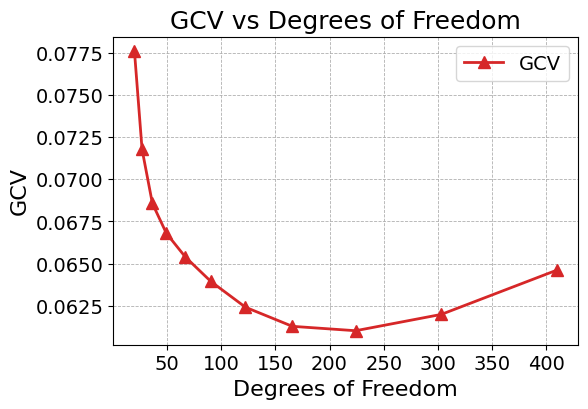

In [27]:
# Adjust text sizes for manuscript-quality plots
plt.figure(figsize=(6, 4))
plt.plot(dof_targets, rmse_values, label="RMSE (Noisy)", marker="o", markersize=8, linewidth=2)
plt.plot(dof_targets, rmse_gt_values, label="RMSE (Ground Truth)", marker="s", markersize=8, linewidth=2)
plt.xlabel("Degrees of Freedom", fontsize=16)
plt.ylabel("RMSE", fontsize=16)
plt.legend(fontsize=14)
plt.title("RMSE vs Degrees of Freedom", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle="--", linewidth=0.6)
plt.show()

# Create separate GCV plot with larger text
plt.figure(figsize=(6, 4))
plt.plot(dof_targets, gcv_values, label="GCV", marker="^", color="tab:red", markersize=8, linewidth=2)
plt.xlabel("Degrees of Freedom", fontsize=16)
plt.ylabel("GCV", fontsize=16)
plt.legend(fontsize=14)
plt.title("GCV vs Degrees of Freedom", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle="--", linewidth=0.6)
plt.show()


Running with dof: 20.00
Running with dof: 27.05
Running with dof: 36.59
Running with dof: 49.49
Running with dof: 66.95
Running with dof: 90.55
Running with dof: 122.48
Running with dof: 165.68
Running with dof: 224.10
Running with dof: 303.12
Running with dof: 410.00


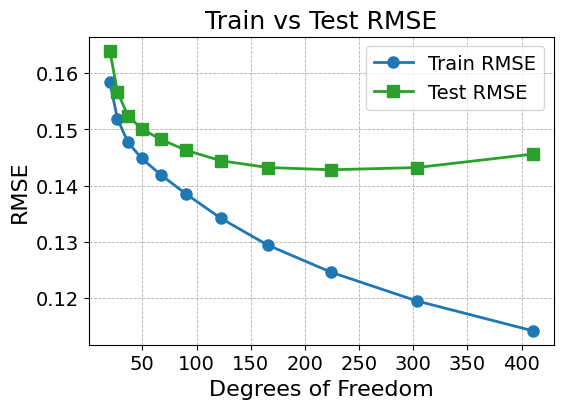

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from flowmap_legacy.TPS import ThinPlateSpline
from sklearn.model_selection import train_test_split

# Define the range of degrees of freedom to test in log space
dof_targets = np.logspace(np.log10(20), np.log10(410), 11)  # Logarithmically spaced values
# Store the computed metrics
rmse_train_values = []
rmse_test_values = []
# Split X_2d into training and testing sets
train_indices, test_indices = train_test_split(np.arange(len(X_2d)), test_size=0.2, random_state=42)
X_train, X_test = X_2d[train_indices], X_2d[test_indices]


# Create TPS model
n_control_points = 500  # Adjust as needed
tps = ThinPlateSpline(X_train, n_control_points=n_control_points)

# Iterate over different degrees of freedom
for dof_target in dof_targets:
    print(f"Running with dof: {dof_target:.2f}")
    tps.fit(X_noisy[train_indices,], dof_target=dof_target)
    
    # Compute RMSE for training and testing sets
    X_train_smoothed = tps.predict(X_train)
    X_test_smoothed = tps.predict(X_test)
    
    RMSE_train = np.sqrt(np.mean((X_noisy[train_indices,] - X_train_smoothed) ** 2))
    RMSE_test = np.sqrt(np.mean((X_noisy[test_indices,] - X_test_smoothed) ** 2))
    
    # Store metrics
    rmse_train_values.append(RMSE_train)
    rmse_test_values.append(RMSE_test)

# Create RMSE plot for train and test
plt.figure(figsize=(6, 4))
plt.plot(dof_targets, rmse_train_values, label="Train RMSE", marker="o", color="tab:blue", markersize=8, linewidth=2)
plt.plot(dof_targets, rmse_test_values, label="Test RMSE", marker="s", color="tab:green", markersize=8, linewidth=2)

# Formatting
plt.xlabel("Degrees of Freedom", fontsize=16)
plt.ylabel("RMSE", fontsize=16)
plt.legend(fontsize=14)
plt.title("Train vs Test RMSE", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle="--", linewidth=0.6)
plt.show()

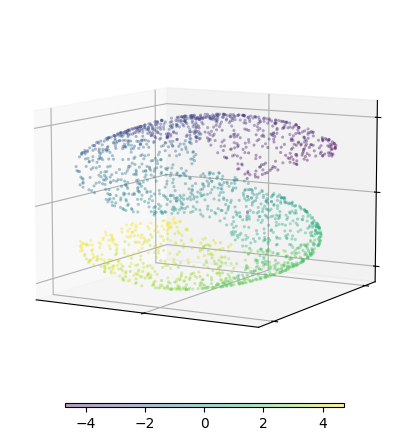

In [29]:
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)
tps.fit(X_noisy, dof_target=20)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)

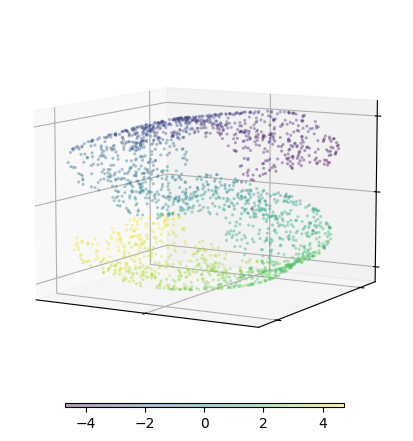

In [30]:
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)
tps.fit(X_noisy, dof_target=50)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)

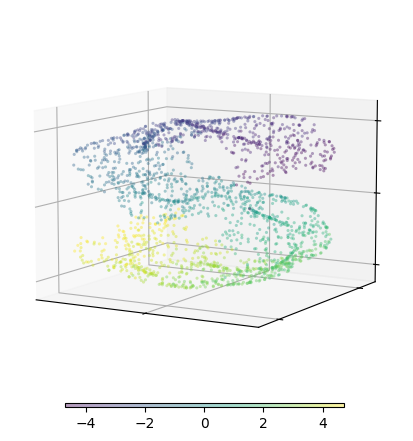

In [31]:
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)
tps.fit(X_noisy, dof_target=100)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)

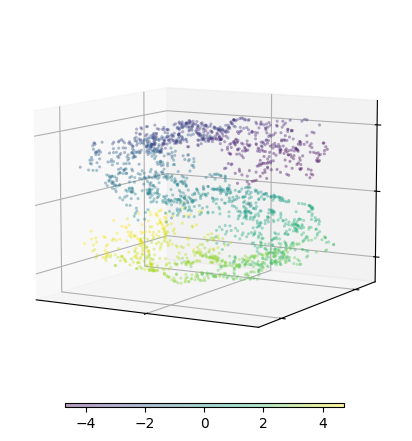

In [32]:
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)
tps.fit(X_noisy, dof_target=400)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)